# Gaussian weighting inside the fixed dynamical core

`FRAC=1` is not tuned. This notebook instead shows how the Gaussian redistributes influence among cells inside that fixed boundary and how much effective sample size is retained.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / "seacofs_tilt_tools.py").exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError("Run inside seacofs_eddy_tilt_analysis or one of its subfolders")
for path in (ANALYSIS_ROOT, HERE):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
import seacofs_tilt_tools as tilt
import esp_pv_tools as ept
sns.set_theme(style="whitegrid", context="notebook")
palette = {"AE":"#c44e52", "CE":"#4c72b0"}


In [2]:
data = ept.load_cache()
focus = data[data.method.isin(["uniform_1", "esp_gaussian_1"])].copy()
r = np.linspace(0, np.sqrt(.5), 500)
uniform_density = 2*r
gaussian_density = 2*r*np.exp(-r**2)
uniform_cdf = np.cumsum(uniform_density); uniform_cdf /= uniform_cdf[-1]
gaussian_cdf = np.cumsum(gaussian_density); gaussian_cdf /= gaussian_cdf[-1]

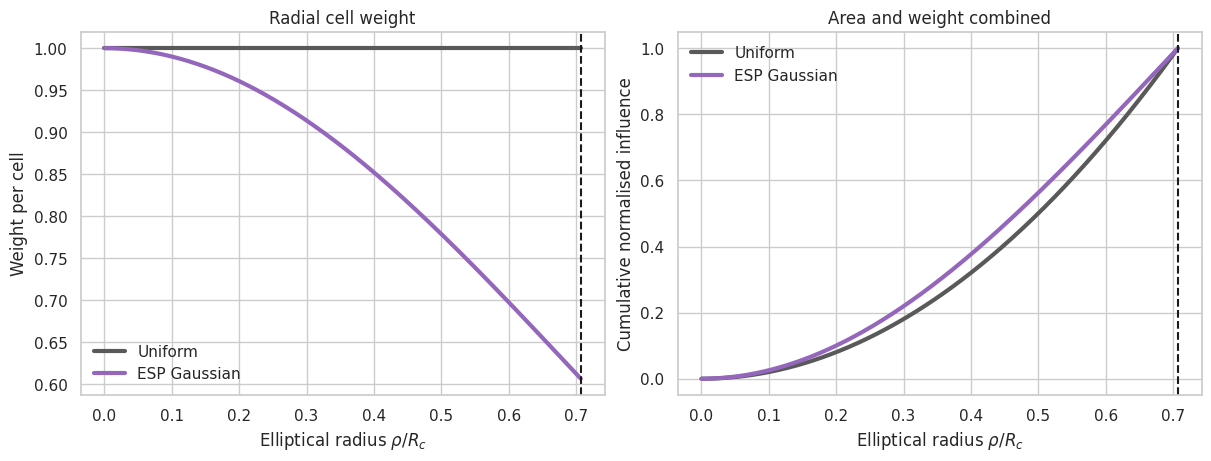

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
axes[0].plot(r, np.ones_like(r), lw=3, color=".35", label="Uniform")
axes[0].plot(r, np.exp(-r**2), lw=3, color="tab:purple", label="ESP Gaussian")
axes[0].axvline(np.sqrt(.5), color="k", ls="--")
axes[0].set(xlabel=r"Elliptical radius $\rho/R_c$", ylabel="Weight per cell", title="Radial cell weight")
axes[0].legend(frameon=False)
axes[1].plot(r, uniform_cdf, lw=3, color=".35", label="Uniform")
axes[1].plot(r, gaussian_cdf, lw=3, color="tab:purple", label="ESP Gaussian")
axes[1].axvline(np.sqrt(.5), color="k", ls="--")
axes[1].set(xlabel=r"Elliptical radius $\rho/R_c$", ylabel="Cumulative normalised influence", title="Area and weight combined")
axes[1].legend(frameon=False)
plt.show()

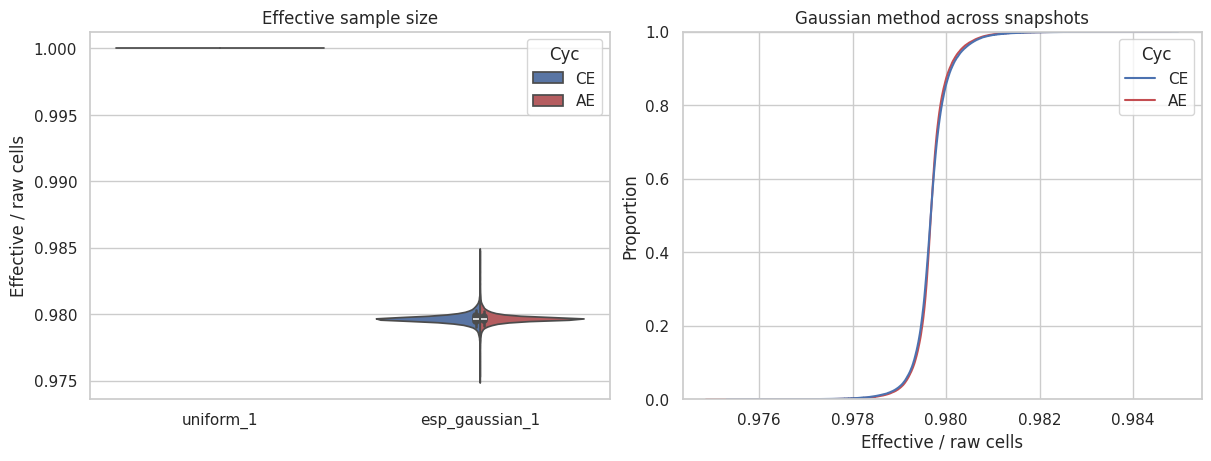

In [4]:
focus["effective_fraction"] = focus.PV_weight_effective_n / focus.PV_footprint_n
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
sns.violinplot(data=focus, x="method", y="effective_fraction", hue="Cyc", split=True, cut=0, palette=palette, ax=axes[0])
sns.ecdfplot(data=focus[focus.method.eq("esp_gaussian_1")], x="effective_fraction", hue="Cyc", palette=palette, ax=axes[1])
axes[0].set(xlabel="", ylabel="Effective / raw cells", title="Effective sample size")
axes[1].set(xlabel="Effective / raw cells", title="Gaussian method across snapshots")
plt.show()